# Phase 2: Exploratory Data Analysis — Panificadora Chask

**Purpose**: Descriptive statistics, distributions, correlation structure, and headline
findings for the 29-month reconstructed dataset (Jan 2020 – May 2022).
All computation is delegated to `src/chask/`; this notebook handles narrative and display.

> **Data disclosure**: All analysis uses `monthly_reconstructed.csv` — a documented
> reconstruction calibrated to the engineering report. Original client records are
> confidential. See the [data dictionary](../docs/data-dictionary.md) for full disclosure.

## Setup

In [1]:
import warnings
import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings('ignore')

from chask.pipeline.ingest import load_raw
from chask.pipeline.validate import validate
from chask.pipeline.transform import to_analytics
from chask.analysis.eda import descriptive_stats, correlation_matrix, headline_findings
from chask.config import INTERVENTION_CUTOFF

df = to_analytics(validate(load_raw()))
pre  = df[df['period'] == 'pre']
post = df[df['period'] == 'post']
cutoff = pd.Timestamp(INTERVENTION_CUTOFF)
print(f'Dataset: {len(df)} months | pre={len(pre)} | post={len(post)}')
df.head(3)

Dataset: 29 months | pre=20 | post=9


,fecha,produccion_kg,consumo_kwh,fallas_maquina,mantenimiento,ventas_usd,costos_usd,tiempo_inactividad_horas,intensity_kwh_kg,gross_margin_pct,profit_usd,cost_per_kg,period
0,2020-01-31,13949.0,55402.22,8,3,21349.0,16695.0,24.1,3.971770,21.799616,4654.0,1.196860,pre
1,2020-02-29,14855.0,53185.39,7,2,23034.0,16862.0,22.9,3.580302,26.795172,6172.0,1.135106,pre
2,2020-03-31,13363.0,56047.00,9,3,20701.0,16897.0,28.0,4.194193,18.375924,3804.0,1.264462,pre


## 1. Dataset Overview

The dataset covers 29 months: **pre-period** (Jan 2020 – Aug 2021, n=20)
and **post-period** (Sep 2021 – May 2022, n=9).
Intervention cutoff: **August 31, 2021** — when the new IE3 motor fleet
and PLC automation system became fully operational.

In [2]:
key_cols = ['consumo_kwh', 'intensity_kwh_kg', 'gross_margin_pct',
            'produccion_kg', 'fallas_maquina', 'tiempo_inactividad_horas']
stats = descriptive_stats(df)
# Select mean/std for key columns
pairs = [(c, p) for c in key_cols for p in ['pre', 'post'] if (c, p) in stats.columns]
stats.loc[['mean', 'std'], pairs].round(2)

consumo_kwh           intensity_kwh_kg       gross_margin_pct         \
             pre      post              pre  post              pre   post   
mean    51826.45  41689.04             3.81  2.76            21.44  28.96   
std      2665.15   2623.72             0.39  0.40             4.61   5.30   

     produccion_kg           fallas_maquina       tiempo_inactividad_horas  \
               pre      post            pre  post                      pre   
mean      13680.20  15249.22           8.05  4.33                    26.86   
std         963.37   1286.17           1.50  3.20                     7.99   

             
       post  
mean  15.67  
std   11.00

## 2. Time Series — Energy and Production

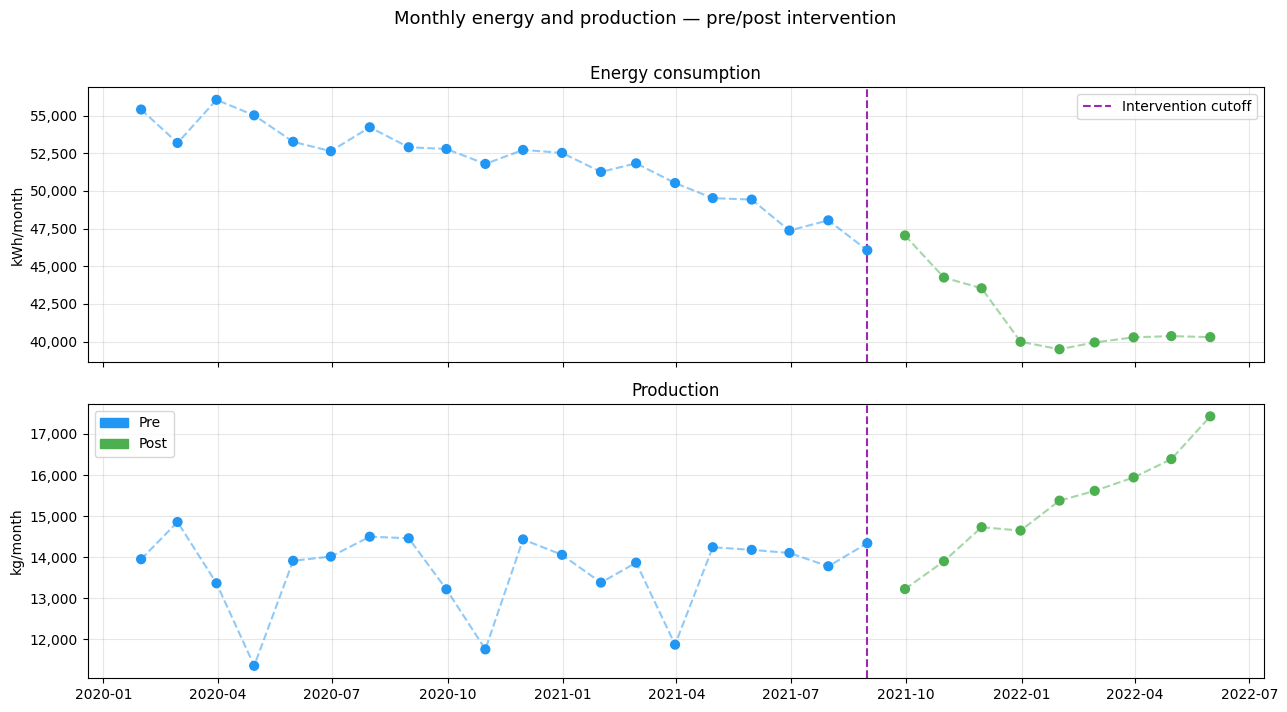

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

colors = df['period'].map({'pre': '#2196F3', 'post': '#4CAF50'})

ax1.scatter(df['fecha'], df['consumo_kwh'], c=colors, s=40, zorder=3)
ax1.plot(pre['fecha'], pre['consumo_kwh'], '--', color='#2196F3', alpha=0.5)
ax1.plot(post['fecha'], post['consumo_kwh'], '--', color='#4CAF50', alpha=0.5)
ax1.axvline(cutoff, ls='--', color='#9C27B0', lw=1.5, label='Intervention cutoff')
ax1.set_ylabel('kWh/month'); ax1.set_title('Energy consumption')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.legend(); ax1.grid(alpha=0.3)

ax2.scatter(df['fecha'], df['produccion_kg'], c=colors, s=40, zorder=3)
ax2.plot(pre['fecha'], pre['produccion_kg'], '--', color='#2196F3', alpha=0.5)
ax2.plot(post['fecha'], post['produccion_kg'], '--', color='#4CAF50', alpha=0.5)
ax2.axvline(cutoff, ls='--', color='#9C27B0', lw=1.5)
ax2.set_ylabel('kg/month'); ax2.set_title('Production')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.grid(alpha=0.3)

from matplotlib.patches import Patch
ax2.legend(handles=[Patch(color='#2196F3', label='Pre'), Patch(color='#4CAF50', label='Post')])

fig.suptitle('Monthly energy and production — pre/post intervention', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Both energy consumption and production show a clear structural break at the intervention
cutoff. The Sep–Oct 2021 commissioning spike in failures is visible in the reliability
module; steady-state (Dec 2021+) shows sustained improvement.

## 3. Box Plots — Pre vs. Post

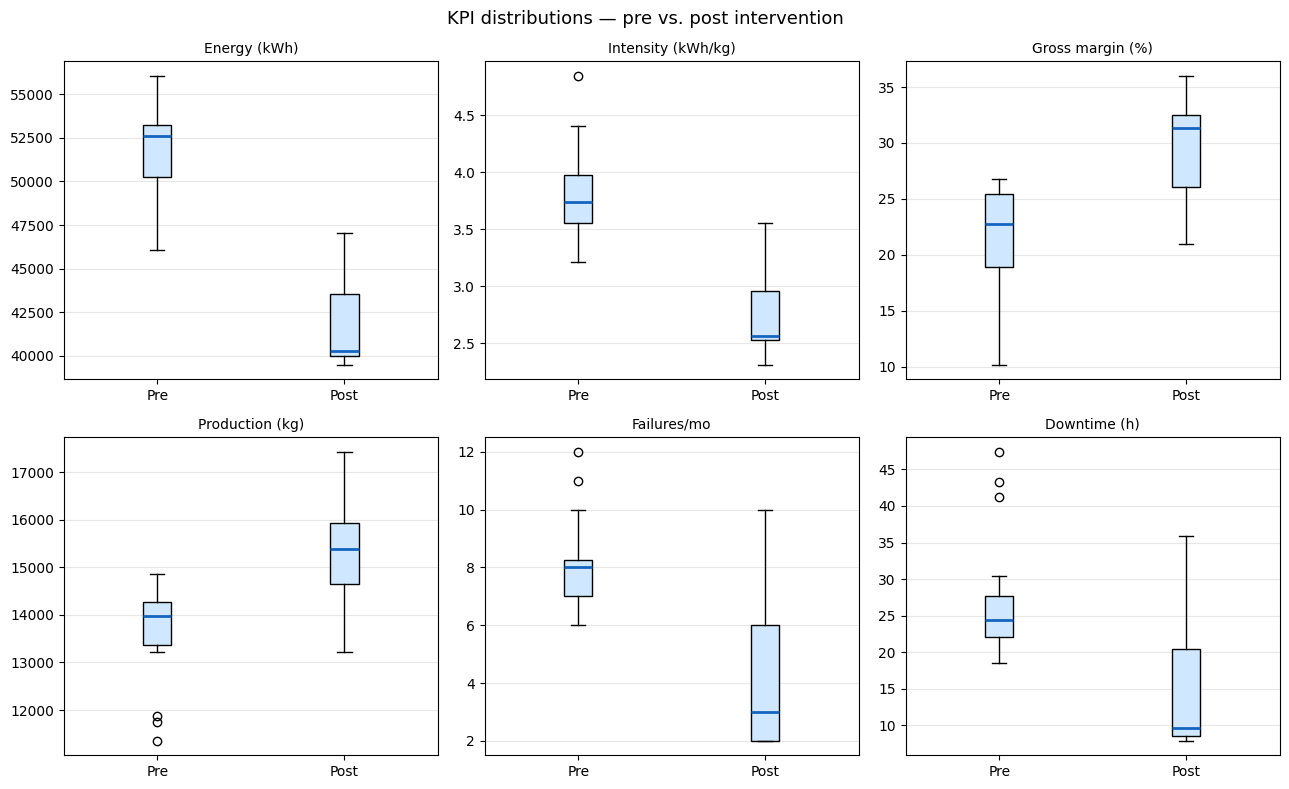

In [4]:
plot_pairs = [
    ('consumo_kwh', 'Energy (kWh)'),
    ('intensity_kwh_kg', 'Intensity (kWh/kg)'),
    ('gross_margin_pct', 'Gross margin (%)'),
    ('produccion_kg', 'Production (kg)'),
    ('fallas_maquina', 'Failures/mo'),
    ('tiempo_inactividad_horas', 'Downtime (h)'),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, (col, label) in zip(axes.flat, plot_pairs):
    ax.boxplot(
        [pre[col].dropna(), post[col].dropna()],
        labels=['Pre', 'Post'],
        patch_artist=True,
        boxprops=dict(facecolor='#CFE8FF'),
        medianprops=dict(color='#1565C0', lw=2),
    )
    ax.set_title(label, fontsize=10)
    ax.grid(alpha=0.3, axis='y')

fig.suptitle('KPI distributions — pre vs. post intervention', fontsize=13)
plt.tight_layout()
plt.show()

All six KPI distributions shift in the expected direction after the intervention.
Energy metrics show the largest absolute shifts; gross margin distribution
is tighter post-intervention (less variance).

## 4. Correlation Matrix

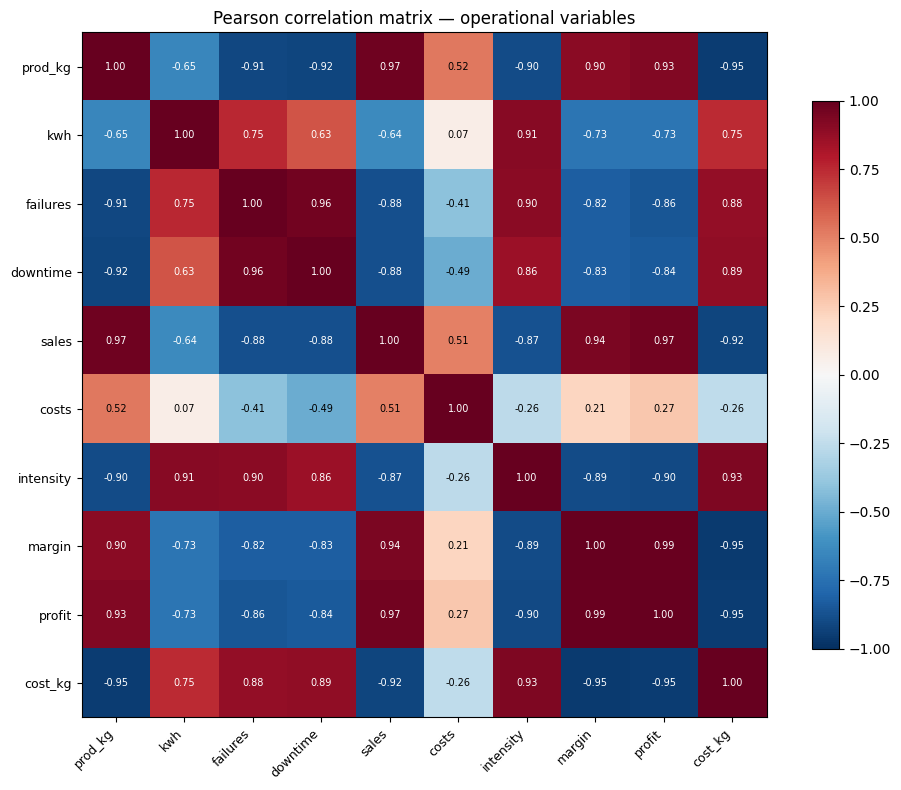

In [5]:
import numpy as np

corr = correlation_matrix(df)
short_names = {
    'produccion_kg': 'prod_kg',
    'consumo_kwh': 'kwh',
    'fallas_maquina': 'failures',
    'tiempo_inactividad_horas': 'downtime',
    'ventas_usd': 'sales',
    'costos_usd': 'costs',
    'intensity_kwh_kg': 'intensity',
    'gross_margin_pct': 'margin',
    'profit_usd': 'profit',
    'cost_per_kg': 'cost_kg',
}
corr_display = corr.rename(index=short_names, columns=short_names)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_display.values, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(range(len(corr_display.columns)))
ax.set_yticks(range(len(corr_display.index)))
ax.set_xticklabels(corr_display.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr_display.index, fontsize=9)
for i in range(len(corr_display)):
    for j in range(len(corr_display.columns)):
        ax.text(j, i, f'{corr_display.values[i, j]:.2f}',
                ha='center', va='center', fontsize=7,
                color='white' if abs(corr_display.values[i, j]) > 0.6 else 'black')
ax.set_title('Pearson correlation matrix — operational variables', fontsize=12)
plt.tight_layout()
plt.show()

Key observations:
- `kwh` and `failures` are positively correlated — more failures coincide with higher energy draw.
- `intensity` and `prod_kg` are negatively correlated — higher throughput improves kWh/kg.
- `margin` is strongly negatively correlated with `costs` and `cost_kg`.

## 5. Headline Findings Table

In [6]:
hf = headline_findings(df)
hf.round({'pre_mean': 1, 'post_mean': 1})

,metric,pre_mean,post_mean,change,direction
0,Energy consumption (kWh),51826.5,41689.0,-19.6%,improved
1,Energy intensity (kWh/kg),3.8,2.8,-27.5%,improved
2,Gross margin (%),21.4,29.0,+7.5 pp,improved
3,Sales (USD),20755.8,23099.9,+11.3%,improved
4,Machine failures /month,8.0,4.3,-46.2%,improved
5,Downtime (h/month),26.9,15.7,-41.7%,improved
6,Production (kg),13680.2,15249.2,+11.5%,improved


All 7 metrics improved. The `direction` column confirms no regressions in the post-period.

**Sep–Oct 2021 commissioning note**: Machine failures spiked (10, 9/month vs. pre mean 8.1)
before stabilizing at 2–3/month in steady-state (Dec 2021+). The post-period average
(4.3/month) already accounts for this spike and is still 46.2% below the pre mean.

---
*Anomaly detection: `02_anomaly_detection.ipynb` · Statistical tests: `03_statistical_tests.ipynb`*